In [1262]:
import numpy as np
import pandas as pd

In [1263]:
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [1264]:
df = pd.read_csv("datasets/train.csv", usecols=['Age', 'Fare', 'Survived'])

In [1265]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [1266]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [1267]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

C:\Users\Pappu\AppData\Local\Temp\ipykernel_7976\1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [1268]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [1269]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [1270]:
X = df.iloc[:, 1:3]
y = df.iloc[:, 0]

In [1271]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

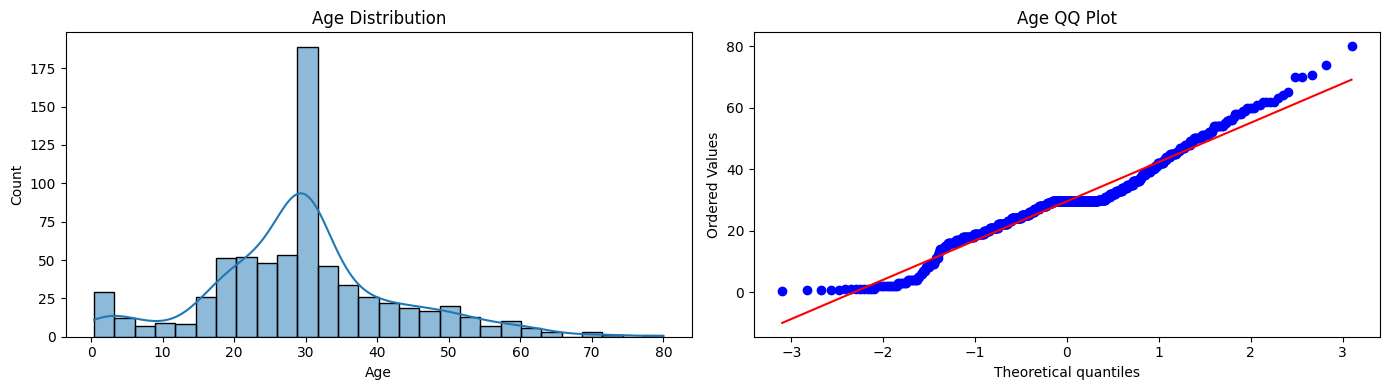

In [1272]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1,figsize=(14, 4))

# Plot histogram with KDE using seaborn's histplot on the first subplot
sns.histplot(X_train['Age'], kde=True, ax=ax1)
ax1.set_title("Age Distribution")

# Plot QQ plot on the second subplot
stats.probplot(X_train['Age'], dist='norm', plot=ax2)
ax2.set_title("Age QQ Plot")

plt.tight_layout()
plt.show()

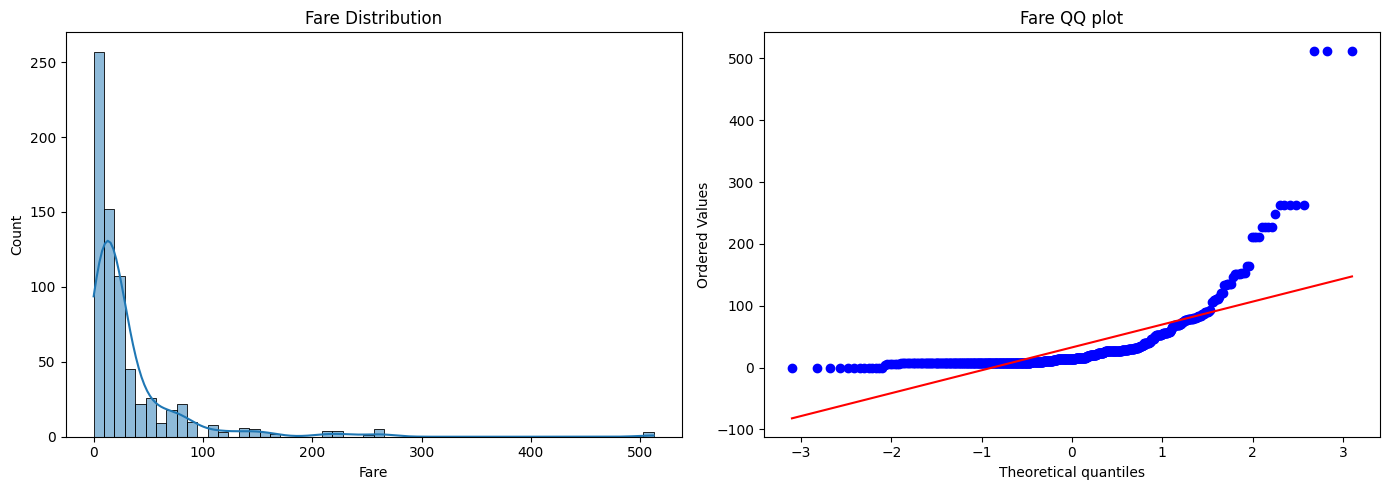

In [1273]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14,5))

sns.histplot(X_train['Fare'], kde=True, ax=ax1)
ax1.set_title("Fare Distribution")

stats.probplot(X_train['Fare'], dist='norm', plot=ax2)
ax2.set_title("Fare QQ plot")

plt.tight_layout()
plt.show()

In [1274]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [1275]:
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)

y_pred = clf1.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("Accuracy score LR", accuracy_score(y_test,y_pred))
print("Accuracy score DT", accuracy_score(y_test,y_pred1))

Accuracy score LR 0.6480446927374302
Accuracy score DT 0.664804469273743


In [1276]:
trf = FunctionTransformer(func=np.log1p)

In [1277]:
X_train_transform = trf.fit_transform(X_train)
X_test_transform = trf.transform(X_test)

In [1278]:
clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf1.fit(X_train_transform, y_train)
clf2.fit(X_train_transform, y_train)

y_pred = clf1.predict(X_test_transform)
y_pred1 = clf2.predict(X_test_transform)

print("Accuracy score LR", accuracy_score(y_test,y_pred))
print("Accuracy score DT", accuracy_score(y_test,y_pred1))

Accuracy score LR 0.6815642458100558
Accuracy score DT 0.6703910614525139


In [1279]:
X_transform = trf.fit_transform(X)

clf1 = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf1, X_transform, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transform, y, scoring='accuracy', cv=10)))

LR 0.678027465667915
DT 0.6666791510611735


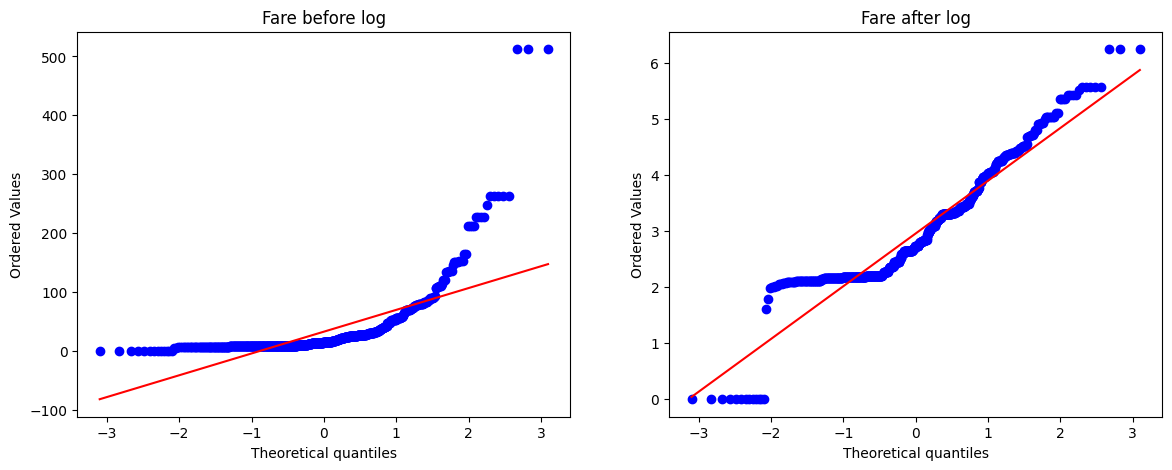

In [1280]:
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14,5))

stats.probplot(X_train['Fare'], dist='norm', plot=ax1)
ax1.set_title("Fare before log")

stats.probplot(X_train_transform['Fare'], dist='norm', plot=ax2)
ax2.set_title("Fare after log")

plt.show()

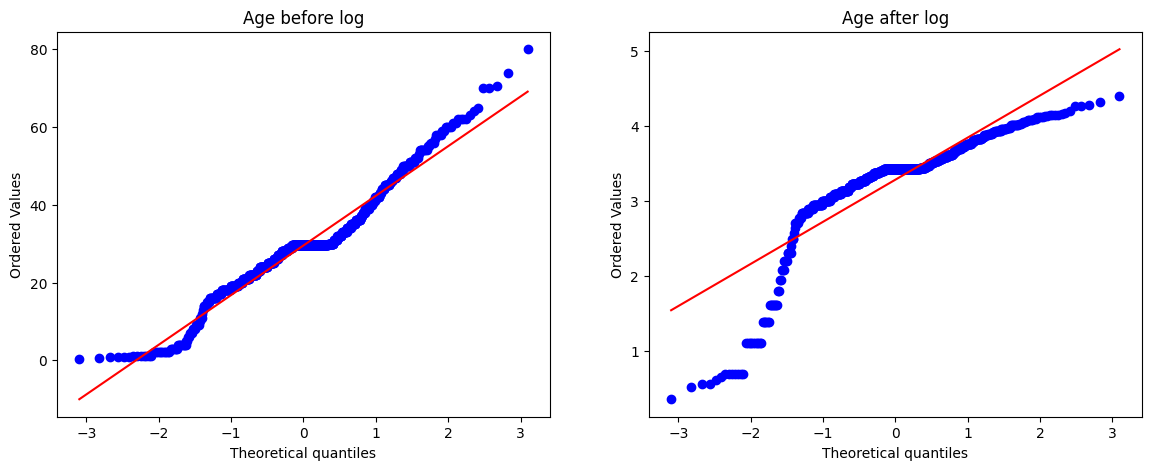

In [1281]:
fig,(ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(14,5))

stats.probplot(X_train['Age'], dist='norm', plot=ax1)
ax1.set_title("Age before log")

stats.probplot(X_train_transform['Age'], dist='norm', plot=ax2)
ax2.set_title("Age after log")

plt.show()

In [1339]:
trf2 = ColumnTransformer([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one'), ['Fare'])
], remainder='passthrough')

In [1340]:
X_train_transformed = trf2.fit_transform(X_train)
X_test_transformed = trf2.transform(X_test)

In [1341]:
trf2.get_feature_names_out()

array(['log__Fare', 'remainder__Age'], dtype=object)

In [1284]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed, y_train)
clf2.fit(X_train_transformed, y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

In [1285]:
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.6703910614525139
Accuracy DT 0.6871508379888268


In [1286]:
X_transformed2 = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR", np.mean(cross_val_score(clf, X_transformed2, y, scoring='accuracy', cv=10)))
print("DT", np.mean(cross_val_score(clf2, X_transformed2, y, scoring='accuracy', cv=10)))

LR 0.6712609238451936
DT 0.6610861423220974


In [1332]:
def apply_transform(transform):
    X = df.iloc[:, 1:3]
    y = df.iloc[:, 0]

    trf = ColumnTransformer([('log', FunctionTransformer(transform), ['Fare'])], remainder='passthrough')
    X_train = trf.fit_transform(X)

    clf=LogisticRegression()

    print("Accuracy", np.mean(cross_val_score(clf, X_train, y, scoring='accuracy', cv=10)))

    fig, (ax1, ax2) = plt.subplots(ncols=2, nrows = 1, figsize=(14,6))

    stats.probplot(X['Fare'], dist = 'norm', plot = ax1)
    ax1.set_title("Fare before tranform")

    stats.probplot(X_train[:, 0], dist='norm', plot=ax2)
    ax2.set_title("Fare after tranform")
    
    plt.tight_layout()
    plt.show()

Accuracy 0.6611485642946316


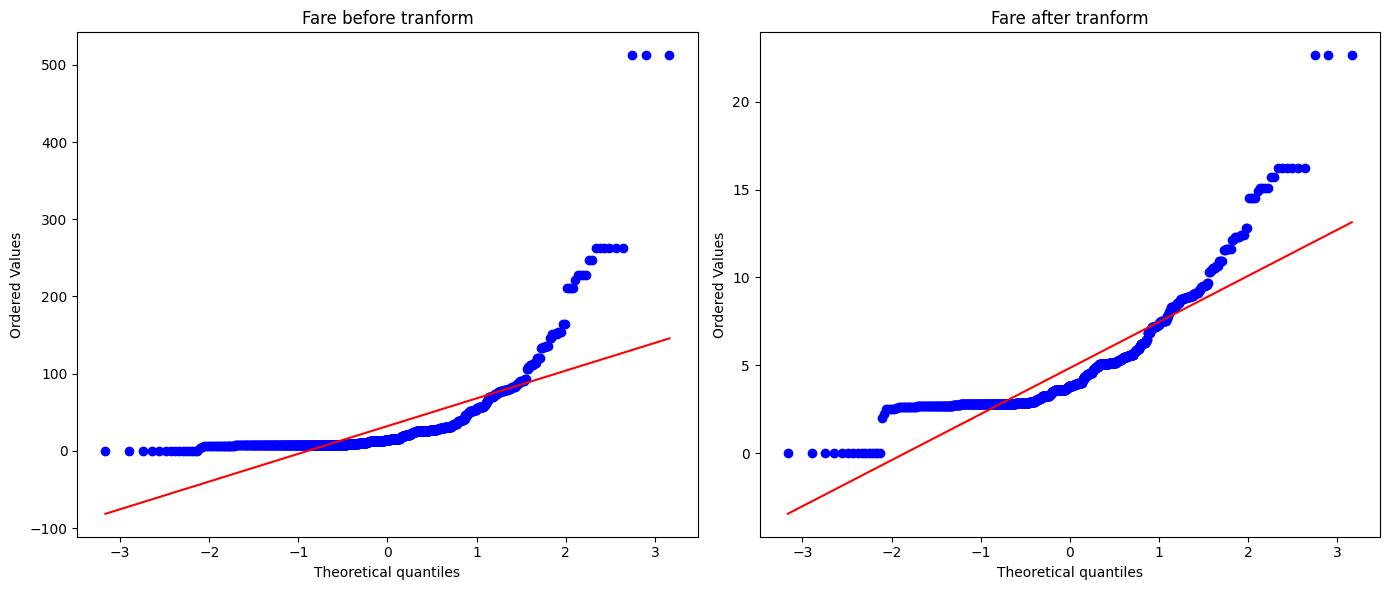

In [1333]:
apply_transform(lambda x: np.sqrt(x))

Accuracy 0.61729088639201


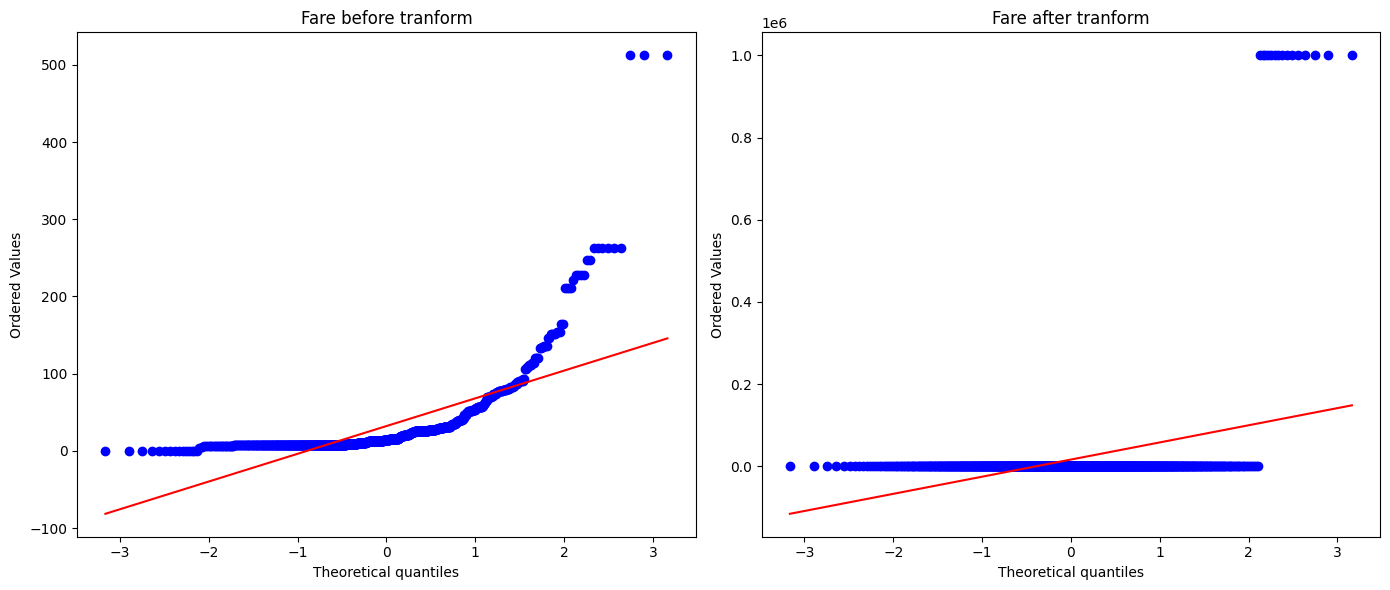

In [1334]:
apply_transform(lambda x:  1/(x+0.000001))